In [16]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# What are the most demanded skills for the top 3 data careers?

## Objective

Compare the most frequently requested technical skills across the three most common data careers:

- Data Analyst
- Data Scientist
- Data Engineer

## Methodology

1. Clean the skills column
2. Explode one skill per row
3. Count skills by job title
4. Calculate demand percentages
5. Visualize the results

In [17]:
# =====================================
# Keep only the three major data careers
# =====================================

job_titles = [
    "Data Analyst",
    "Data Scientist",
    "Data Engineer"
]

df_US = df[
    (df["job_country"] == "United States") &
    (df["job_title_short"].isin(job_titles))
].copy()

df_US.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","[sql, python, r, mongodb, mongodb, sql server,...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"[python, qlik]","{'analyst_tools': ['qlik'], 'programming': ['p..."
17,Data Scientist,Data Science Team Lead,"Laurel, MD",via APL Careers - Johns Hopkins University App...,Full-time,False,Georgia,2023-06-13 13:25:17,False,True,United States,NaN,NaN,NaN,Johns Hopkins Applied Physics Laboratory,"[go, apl, excel]","{'analyst_tools': ['excel'], 'programming': ['..."


In [18]:
# =====================================
# One row per skill
# =====================================

df_skills = df_US.explode("job_skills")

df_skills.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,python,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,c++,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,java,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,matlab,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,aws,"{'cloud': ['aws'], 'libraries': ['tensorflow',..."


In [19]:
# =====================================
# Count skills by job title
# =====================================

df_skills_count = (
    df_skills
        .groupby(["job_skills", "job_title_short"])
        .size()
        .reset_index(name="skill_count")
)

df_skills_count.sort_values(
    by="skill_count",
    ascending=False,
    inplace=True
)

df_skills_count

,job_skills,job_title_short,skill_count
436,python,Data Scientist,42379
538,sql,Data Analyst,34452
540,sql,Data Scientist,30034
167,excel,Data Analyst,27519
448,r,Data Scientist,26022
...,...,...,...
312,mattermost,Data Scientist,1
82,clickup,Data Scientist,1
510,shogun,Data Scientist,1
75,chainer,Data Analyst,1


In [20]:
# =====================================
# Count jobs for each profession
# =====================================

df_job_title_count = (
    df_US["job_title_short"]
        .value_counts()
        .reset_index(name="jobs_total")
        .rename(columns={"job_title_short":"job_title_short"})
)

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080


In [21]:
# =====================================
# Calculate skill percentages
# =====================================

df_skills_perc = pd.merge(
    df_skills_count,
    df_job_title_count,
    on="job_title_short",
    how="left"
)

df_skills_perc["skill_percent"] = (
    df_skills_perc["skill_count"]
    / df_skills_perc["jobs_total"]
    * 100
)

df_skills_perc.head()

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534


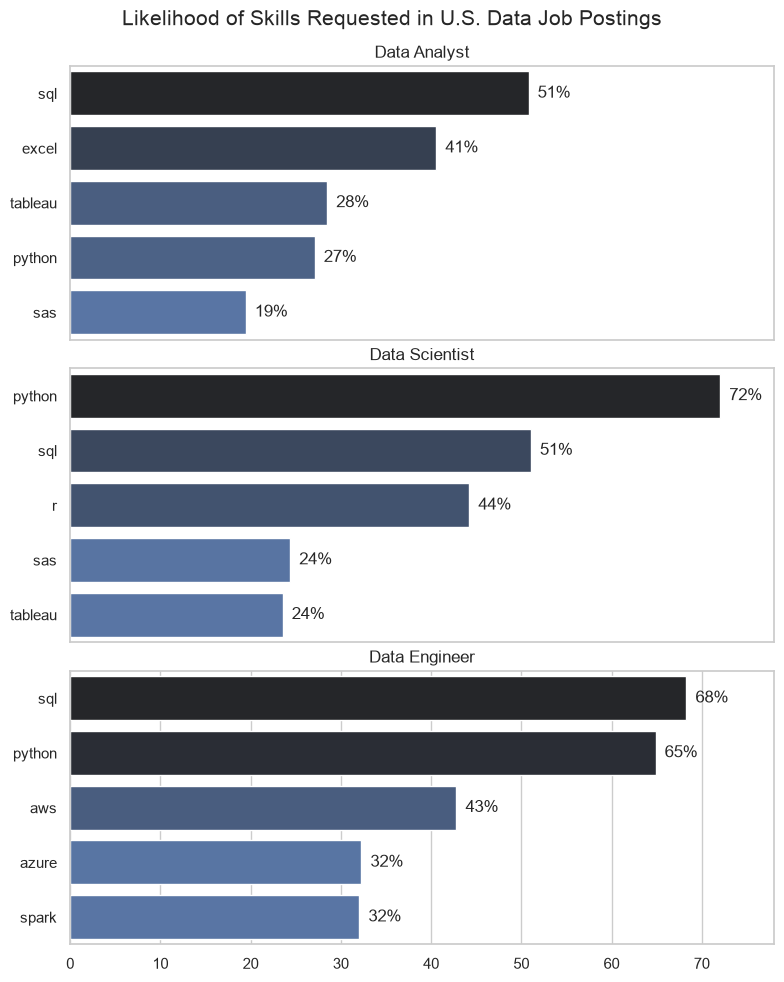

In [23]:
# ============================================
# Compare the top 5 most demanded skills
# for each data profession
# ============================================

# Create one subplot (chart) for each job title
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8, 10))

# Apply a clean Seaborn style
sns.set_theme(style="ticks")

# Loop through each profession
for i, job_title in enumerate(job_titles):

    # Keep only the current profession
    # and select the top 5 skills by percentage
    df_plot = (
        df_skills_perc[
            df_skills_perc["job_title_short"] == job_title
        ]
        .sort_values("skill_percent", ascending=False)
        .head(5)
    )

    # Draw the horizontal bar chart
    sns.barplot(
        data=df_plot,
        x="skill_percent",      # Percentage of jobs requiring the skill
        y="job_skills",         # Skill names
        hue="skill_count",      # Color intensity based on raw demand
        palette="dark:b_r",
        ax=ax[i]
    )

    # Chart title
    ax[i].set_title(job_title)

    # Remove unnecessary labels
    ax[i].set_ylabel("")
    ax[i].set_xlabel("")

    # Remove redundant legend
    ax[i].get_legend().remove()

    # Keep every chart on the same scale
    ax[i].set_xlim(0, 78)

    # Display percentage at the end of each bar
    for n, value in enumerate(df_plot["skill_percent"]):
        ax[i].text(
            value + 1,          # Slightly right of the bar
            n,                  # Current bar position
            f"{value:.0f}%",    # Display as whole-number percentage
            va="center"
        )

    # Hide x-axis ticks except for the bottom chart
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

# Overall figure title
fig.suptitle(
    "Likelihood of Skills Requested in U.S. Data Job Postings",
    fontsize=15
)

# Reduce overlap between charts
fig.tight_layout(h_pad=0.5)

# Display the finished figure
plt.show()